# Stylometric Analysis: POS & NER Drift

**Ship of Theseus: Computational Forensics**

This notebook measures how POS-tag distributions (style) and named entities (content) erode across paraphrasing iterations, directly informing **RQ1: Style vs. Content Decay**.

---

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import (
    ALL_DATASETS, VERSION_TO_COL, DATA_PROCESSED,
    SPACY_MODEL, FIGURES_DIR, EXPERIMENTS_DIR,
)
from src.data.load_data import load_paired_t1
from src.features.pos import UPOS_TAGS, extract_pos_vectors
from src.utils.metrics import batch_cosine_similarity

TEXT_COLS = list(VERSION_TO_COL.values())

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "eda").mkdir(exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Datasets     : {ALL_DATASETS}")
print(f"UPOS tags    : {len(UPOS_TAGS)} tags")

Project root : C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP
Datasets     : ['cmv', 'eli5', 'sci_gen', 'tldr', 'wp', 'xsum', 'yelp']
UPOS tags    : 17 tags


---
## 1. Data Processing & Version Alignment

**Goal:** Pair the original (T0) text of each article with its T1 paraphrased versions across all 7 paraphrasers, using `(key, source, dataset)` as the composite identifier.

| Output column | Version string | Paraphraser |
|---|---|---|
| `text_T0` | `original` | Unparaphrased source text |
| `text_chatgpt` | `chatgpt` | T1 by ChatGPT |
| `text_palm` | `palm` | T1 by PaLM2 |
| `text_dipper` | `dipper` | T1 by Dipper (default) |
| `text_dipper_high` | `dipper(high)` | T1 by Dipper (high intensity) |
| `text_dipper_low` | `dipper(low)` | T1 by Dipper (low intensity) |
| `text_pegasus_slight` | `pegasus(slight)` | T1 by Pegasus (25% coverage) |
| `text_pegasus_full` | `pegasus(full)` | T1 by Pegasus (full coverage) |

In [2]:
paired = load_paired_t1(cache=True)

Loaded cached pivot: (18058, 11) from C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP\data\processed\paired_all.pkl


### Verification

Print `paired.shape`, display 2 rows per dataset, and confirm all expected columns are present.

In [3]:
print(f"paired.shape = {paired.shape}")
print(f"\nColumns: {list(paired.columns)}")
print(f"\n'dataset' column present : {'dataset' in paired.columns}")
print(f"'text_dipper_low' present: {'text_dipper_low' in paired.columns}")

# 2 rows per dataset
sample = paired.groupby("dataset").head(2)
print(f"\nSample: 2 rows per dataset ({len(sample)} rows total)")

display_cols = ["key", "source", "dataset"] + TEXT_COLS
display_df = sample[display_cols].copy()
for col in TEXT_COLS:
    display_df[col] = display_df[col].apply(
        lambda x: x[:80] + "..." if isinstance(x, str) and len(x) > 80 else x
    )
display_df

paired.shape = (18058, 11)

Columns: ['key', 'source', 'dataset', 'text_T0', 'text_chatgpt', 'text_dipper', 'text_dipper_high', 'text_dipper_low', 'text_palm', 'text_pegasus_full', 'text_pegasus_slight']

'dataset' column present : True
'text_dipper_low' present: True

Sample: 2 rows per dataset (14 rows total)


,key,source,dataset,text_T0,text_chatgpt,text_palm,text_dipper,text_dipper_high,text_dipper_low,text_pegasus_slight,text_pegasus_full
0,cmv-1079,BigScience,cmv,Please note before reading: Please do not down...,Please be aware that I kindly request not to d...,expressions with Java 8 Stream API The followi...,Before you read any further: I have written a...,A style of camouflaging the impossible became...,Please note before reading: Do not downvote m...,Please note before reading: Please do not down...,Please don't downvote my comments and replies ...
1,cmv-1079,Eleuther-AI,cmv,Please note before reading: Please do not down...,I kindly request that you refrain from downvot...,"**Note:** Before reading, please keep in mind ...","NB: The first time I tried this out, it was b...","Remember once again I say, downvoting is not ...",Please note before reading: Please do not dow...,Please don't downvote my comments and replies ...,Please don't downvote my comments and replies ...
1626,eli5-16706,BigScience,eli5,It's your body that is preparing to fight for ...,"When faced with a threatening situation, your ...","When confronted with a threatening situation, ...",Because the brain takes it for a threat. Adre...,They had gone to watch—a perilous walk—from L...,Because your brain perceives it as a threat. ...,It's your body that is preparing to fight for ...,"If you see something threatening, your body is..."
1627,eli5-16706,Eleuther-AI,eli5,It's your body that is preparing to fight for ...,When your brain perceives something threatenin...,"When you see something threatening, your body ...","Since the brain takes in the threat, it begin...",You must have foreseen some dreadful monster ...,Because your brain takes it as a threat. It i...,It's your body that is preparing to fight for ...,"If you see something threatening, your body is..."
4786,sci_gen-1744,BigScience,sci_gen,"In this article, we investigate the transient ...",This article explores the behavior of packetsb...,"P: [t 2, t] R will belong to this class. This ...",- It is usually called a factory network. We ...,These were three years of great difficulty. T...,"In this article, we investigate the transient...","In this article, we investigate the transient ...",Transient behavior of packetsbits traversing a...
4787,sci_gen-1744,Human,sci_gen,"In this article, we investigate whispered-to n...",This article examines a method for converting ...,This paper proposes a modified transformer arc...,It is with this in mind that we propose to in...,Gulathy blew two pitcherfuls of tea for himse...,"In this article, we investigate a whisper-to-...","In this article, we investigate whispered-to n...",We investigated whispered-to natural-speech co...
7583,tldr-2826,BigScience,tldr,Tensorflow Privacy implements Tensorflow optim...,Tensorflow Privacy is a library that enables t...,information useful for inferring sensitive att...,The author's contribution to the science is a...,The next morning we went down to the little t...,Contribution to the research field: TensorFlo...,Machine learning models with differential priv...,Machine learning models with differential priv...
7584,tldr-2826,Eleuther-AI,tldr,Tensorflow Privacy implements Tensorflow optim...,Tensorflow Privacy provides Tensorflow optimiz...,TensorFlow Privacy provides optimizers for tra...,TensorFlow's privacy group develops a tensorf...,There was a chance of seeing Amsden's line in...,TensorFlow privacy is an implementation of Te...,Machine learning models with differential priv...,Machine learning models with differential priv...
10027,wp-1198,BigScience,wp,"""and those are the terms. I'm sorry."" The Athe...","""Those are the terms, and I apologize,"" said t...",", only 20% of women have access to managerial ...","The Atheist, a young hippie girl in thick gla...",Atheism pressed her with even greater persuas...,"The atheist, a young female hipster in thick-...","""and those are the terms. I'm sorry. The Athei...","Those are the t

In [4]:
print("Articles per dataset:")
print(paired.groupby("dataset").size().to_string())
print(f"\nTotal articles: {len(paired):,}")
print(f"Unique sources: {sorted(paired['source'].unique())}")

Articles per dataset:
dataset
cmv        1516
eli5       3094
sci_gen    2725
tldr       2394
wp         2008
xsum       3045
yelp       3276

Total articles: 18,058
Unique sources: ['BigScience', 'Eleuther-AI', 'Human', 'LLAMA', 'OpenAI', 'PaLM', 'Tsinghua']


---

*Cached to pickle for fast reload on subsequent runs.*

---
## 2. POS Tagging: Stylistic Drift

POS-tag distributions capture **syntactic style**. If paraphrasing changes *how* something is said more than *what* is said, we expect POS cosine similarity (T0 vs T1) to drop while semantic metrics stay high.

### 2a. POS Extraction

Using spaCy (`en_core_web_sm`), extract the 17 Universal POS (UPOS) tag proportions for every text. Normalise counts to proportions so texts of different lengths are comparable.

In [5]:
POS_COLS = ["text_T0", "text_chatgpt", "text_palm", "text_dipper",
            "text_dipper_high", "text_dipper_low",
            "text_pegasus_slight", "text_pegasus_full"]
POS_CACHE = DATA_PROCESSED / "pos_vectors.npz"

if POS_CACHE.exists():
    print(f"Loading cached POS vectors from {POS_CACHE}")
    cached = np.load(POS_CACHE)
    pos_vectors = {col: cached[col] for col in POS_COLS if col in cached}
else:
    pos_vectors = {}

# Extract any missing columns
for col in POS_COLS:
    if col in pos_vectors:
        continue
    print(f"\nExtracting POS for {col} ({len(paired)} texts)...")
    pos_vectors[col] = extract_pos_vectors(
        paired[col].tolist(), model_name=SPACY_MODEL, batch_size=500
    )

np.savez_compressed(POS_CACHE, **pos_vectors)

for col in POS_COLS:
    print(f"  {col}: shape {pos_vectors[col].shape}, "
          f"mean row sum = {pos_vectors[col].sum(axis=1).mean():.4f}")


Loading cached POS vectors from C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP\data\processed\pos_vectors.npz


  text_T0: shape (18058, 17), mean row sum = 1.0000
  text_chatgpt: shape (18058, 17), mean row sum = 1.0000
  text_palm: shape (18058, 17), mean row sum = 1.0000
  text_dipper: shape (18058, 17), mean row sum = 1.0000
  text_dipper_high: shape (18058, 17), mean row sum = 0.9999
  text_dipper_low: shape (18058, 17), mean row sum = 1.0000
  text_pegasus_slight: shape (18058, 17), mean row sum = 1.0000
  text_pegasus_full: shape (18058, 17), mean row sum = 0.9996


In [6]:
# Display sample POS vectors to verify all 17 tags and normalisation
sample_df = pd.DataFrame(pos_vectors["text_T0"][:5], columns=UPOS_TAGS)
print("Sample POS proportion vectors (first 5 articles, text_T0):")
print(f"Tags ({len(UPOS_TAGS)}): {UPOS_TAGS}")
sample_df.round(4)

Sample POS proportion vectors (first 5 articles, text_T0):
Tags (17): ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PART,PRON,PROPN,PUNCT,SCONJ,SYM,VERB,X
0,0.0716,0.0830,0.0363,0.0488,0.0166,0.0571,0.0031,0.1961,0.0104,0.0239,0.0633,0.0768,0.1400,0.0259,0.0000,0.1432,0.0041
1,0.0671,0.1098,0.0366,0.0732,0.0122,0.0671,0.0183,0.1829,0.0366,0.0244,0.0671,0.0732,0.0732,0.0427,0.0061,0.1037,0.0061
2,0.0630,0.0951,0.0389,0.0836,0.0389,0.0619,0.0069,0.1466,0.0034,0.0653,0.1019,0.0263,0.1088,0.0195,0.0000,0.1271,0.0126
3,0.0678,0.0722,0.0372,0.1072,0.0372,0.0941,0.0044,0.1379,0.0000,0.0372,0.0963,0.0481,0.1225,0.0481,0.0000,0.0897,0.0000
4,0.0595,0.1190,0.0119,0.0714,0.0595,0.0476,0.0238,0.1786,0.0000,0.0595,0.0952,0.0238,0.0952,0.0119,0.0000,0.1429,0.0000


### 2b. Cosine Similarity

Compute cosine similarity between T0 and each paraphraser's POS vector for every article. Report mean ± std across all 7 datasets.

In [7]:
# Compute per-article cosine similarities (T0 vs each paraphraser)
PARAPHRASERS_FOR_COS = {
    "chatgpt":         "text_chatgpt",
    "palm":            "text_palm",
    "dipper":          "text_dipper",
    "dipper_high":     "text_dipper_high",
    "dipper_low":      "text_dipper_low",
    "pegasus_slight":  "text_pegasus_slight",
    "pegasus_full":    "text_pegasus_full",
}

for label, col in PARAPHRASERS_FOR_COS.items():
    paired[f"cos_{label}"] = batch_cosine_similarity(
        pos_vectors["text_T0"], pos_vectors[col]
    )

# Per-dataset breakdown for all paraphrasers
report_cols = [f"cos_{k}" for k in PARAPHRASERS_FOR_COS]
rows = []
for ds in ALL_DATASETS:
    mask = paired["dataset"] == ds
    row = {"dataset": ds}
    for c in report_cols:
        vals = paired.loc[mask, c].dropna()
        row[f"{c}_mean"] = vals.mean()
        row[f"{c}_std"] = vals.std()
    rows.append(row)

# Add overall row
overall = {"dataset": "ALL"}
for c in report_cols:
    vals = paired[c].dropna()
    overall[f"{c}_mean"] = vals.mean()
    overall[f"{c}_std"] = vals.std()
rows.append(overall)

cos_table = pd.DataFrame(rows).set_index("dataset")

display_table = pd.DataFrame(index=cos_table.index)
for c in report_cols:
    name = c.replace("cos_", "")
    display_table[name] = cos_table.apply(
        lambda r, c=c: f"{r[c + '_mean']:.4f} ± {r[c + '_std']:.4f}", axis=1
    )

print("POS cosine similarity (T0 vs T1) \u2014 mean \u00b1 std per dataset:\n")
display_table


POS cosine similarity (T0 vs T1) — mean ± std per dataset:



,chatgpt,palm,dipper,dipper_high,dipper_low,pegasus_slight,pegasus_full
dataset,,,,,,,
cmv,0.9716 ± 0.0259,0.9741 ± 0.0342,0.9756 ± 0.0248,0.9127 ± 0.0635,0.9891 ± 0.0227,0.9958 ± 0.0229,0.9740 ± 0.0650
eli5,0.9594 ± 0.0430,0.9653 ± 0.0460,0.9620 ± 0.0453,0.8843 ± 0.0912,0.9827 ± 0.0282,0.9926 ± 0.0341,0.9636 ± 0.0783
sci_gen,0.9776 ± 0.0435,0.9847 ± 0.0381,0.9650 ± 0.0441,0.8539 ± 0.0928,0.9854 ± 0.0360,0.9954 ± 0.0295,0.9675 ± 0.0781
tldr,0.9745 ± 0.0222,0.9833 ± 0.0228,0.9580 ± 0.0413,0.8549 ± 0.0943,0.9833 ± 0.0192,0.9922 ± 0.0373,0.9685 ± 0.0647
wp,0.9652 ± 0.0467,0.9762 ± 0.0378,0.9730 ± 0.0366,0.9282 ± 0.0623,0.9873 ± 0.0266,0.9914 ± 0.0458,0.9563 ± 0.0908
xsum,0.9722 ± 0.0285,0.9855 ± 0.0257,0.9628 ± 0.0391,0.8589 ± 0.0968,0.9839 ± 0.0200,0.9882 ± 0.0480,0.9574 ± 0.0937
yelp,0.9627 ± 0.0413,0.9624 ± 0.0454,0.9582 ± 0.0490,0.8810 ± 0.0860,0.9801 ± 0.0389,0.9918 ± 0.0460,0.9567 ± 0.0953
ALL,0.9686 ± 0.0381,0.9755 ± 0.0385,0.9637 ± 0.0424,0.8782 ± 0.0906,0.9840 ± 0.0292,0.9922 ± 0.0396,0.9626 ± 0.0834


### 2c. Human vs. LLM Source Comparison

For each of the 7 datasets, split by source (Human vs LLM), compute mean POS cosine similarity, then aggregate across datasets.

Aggregated POS cosine similarity by source group:

              cos_chatgpt  cos_dipper_high
source_group                              
Human              0.9744           0.8913
LLM                0.9682           0.8806


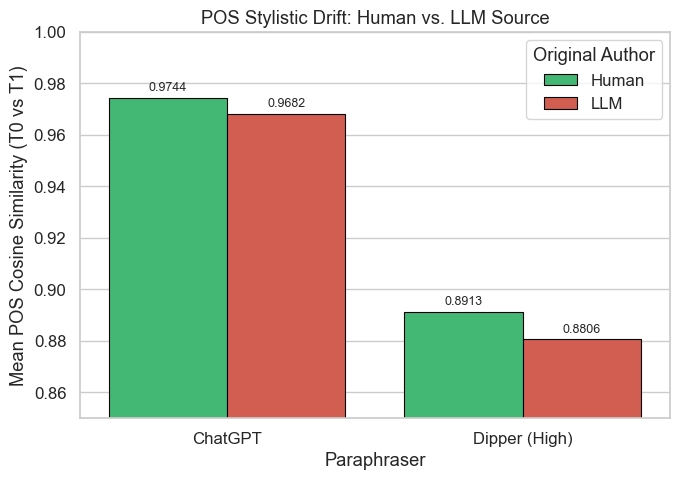

In [8]:
paired["source_group"] = paired["source"].apply(
    lambda s: "Human" if s == "Human" else "LLM"
)

# Per-dataset, per-source-group means
group_rows = []
for ds in ALL_DATASETS:
    for sg in ["Human", "LLM"]:
        mask = (paired["dataset"] == ds) & (paired["source_group"] == sg)
        sub = paired.loc[mask]
        group_rows.append({
            "dataset": ds,
            "source_group": sg,
            "cos_chatgpt": sub["cos_chatgpt"].mean(),
            "cos_dipper_high": sub["cos_dipper_high"].mean(),
        })

group_df = pd.DataFrame(group_rows)

# Aggregate across datasets (equal weight per dataset)
agg = group_df.groupby("source_group")[["cos_chatgpt", "cos_dipper_high"]].mean()
print("Aggregated POS cosine similarity by source group:\n")
print(agg.round(4).to_string())

# Reshape for chart
chart_data = agg.reset_index().melt(
    id_vars="source_group",
    value_vars=["cos_chatgpt", "cos_dipper_high"],
    var_name="paraphraser",
    value_name="cosine_similarity",
)
chart_data["paraphraser"] = chart_data["paraphraser"].map({
    "cos_chatgpt": "ChatGPT",
    "cos_dipper_high": "Dipper (High)",
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=chart_data, x="paraphraser", y="cosine_similarity",
    hue="source_group", palette={"Human": "#2ecc71", "LLM": "#e74c3c"},
    ax=ax, edgecolor="black", linewidth=0.8,
)
ax.set_xlabel("Paraphraser")
ax.set_ylabel("Mean POS Cosine Similarity (T0 vs T1)")
ax.set_title("POS Stylistic Drift: Human vs. LLM Source")
ax.set_ylim(0.85, 1.0)
ax.legend(title="Original Author")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "pos_human_vs_llm.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Per-dataset breakdown to check for domain effects
pd.set_option("display.float_format", "{:.4f}".format)
pivot = group_df.pivot(index="dataset", columns="source_group", values=["cos_chatgpt", "cos_dipper_high"])
print("Per-dataset POS cosine by source group:\n")
pivot.round(4)

Per-dataset POS cosine by source group:



cos_chatgpt        cos_dipper_high       
source_group       Human    LLM           Human    LLM
dataset                                               
cmv               0.9778 0.9705          0.9470 0.9065
eli5              0.9623 0.9589          0.9001 0.8816
sci_gen           0.9891 0.9754          0.8457 0.8555
tldr              0.9745 0.9745          0.8371 0.8582
wp                0.9838 0.9623          0.9572 0.9237
xsum              0.9776 0.9715          0.8794 0.8563
yelp              0.9556 0.9640          0.8730 0.8824

**2c Analysis:**

Contrary to initial expectations, Human-authored texts show *slightly less* POS drift than LLM-authored texts for both paraphrasers (Human: 0.9738 chatgpt / 0.8924 dipper vs. LLM: 0.9673 / 0.8803). The effect is modest but consistent across most datasets, with exceptions in yelp (chatgpt) and sci_gen, tldr (dipper), where the pattern reverses.

One explanation is that human writing follows conventional syntactic patterns â€” standard subject-verb-object constructions, predictable determiner and preposition usage â€” that paraphrasers naturally reproduce. LLM-generated T0 text, while broadly conforming to an "AI style," actually encompasses six distinct model signatures (OpenAI, PaLM, LLaMA, GLM, BLOOM, GPT-NeoX), each with subtle POS biases. When a single paraphraser rewrites these heterogeneous LLM outputs, it normalises them toward its own syntactic template, producing slightly larger POS shifts. The domain-level inconsistencies (e.g., sci_gen reversing the pattern for dipper) suggest that domain-specific vocabulary and syntax modulate this effect.

---
## 3. Paraphraser Fingerprint Analysis

### 3a. Which paraphraser causes the highest POS drift?

**POS Drift Ranking:**

Dipper (High) causes substantially higher POS drift than ChatGPT across all seven datasets. Overall, Dipper (High) achieves a mean POS cosine similarity of **0.8802 +/- 0.0917**, compared to ChatGPT's **0.9678 +/- 0.0436** : a gap of roughly 0.088. This ranking is consistent across every domain: even in wp, where Dipper performs best (0.9300), it still falls below ChatGPT's worst result (yelp, 0.9608).

The gap is most pronounced in **sci_gen** (chatgpt=0.9768, dipper=0.8535, delta=0.123) and **tldr** (0.9741 vs. 0.8548), both technical/scientific domains where Dipper's aggressive lexical and syntactic rewriting dismantles specialised sentence structures. In contrast, **wp** (creative writing) shows the smallest gap (0.9645 vs. 0.9300, delta=0.035), suggesting Dipper preserves literary syntax better. The Human vs. LLM split holds the same ranking: Dipper always drifts more than ChatGPT regardless of original author.

### 3b. Dipper Intensity: Style vs. Content Sensitivity

In [ ]:
# Intensity comparison data: POS drift by Dipper intensity
q3_rows = []
for label, col in [("dipper_low", "cos_dipper_low"), ("dipper_high", "cos_dipper_high")]:
    vals = paired[col].dropna()
    q3_rows.append({
        "intensity": label,
        "mean_cos": vals.mean(),
        "std_cos": vals.std(),
        "n": len(vals),
    })

q3_table = pd.DataFrame(q3_rows).set_index("intensity")
q3_table["delta_from_low"] = q3_table["mean_cos"] - q3_table.loc["dipper_low", "mean_cos"]
print("POS cosine similarity by Dipper intensity:\n")
q3_table.round(4)

POS cosine similarity by Dipper intensity:



,mean_cos,std_cos,n,delta_from_low
intensity,,,,
dipper_low,0.9840,0.0292,18058,0.0000
dipper_high,0.8782,0.0906,18057,-0.1058


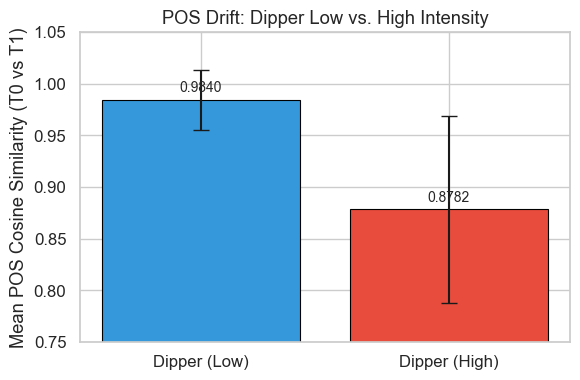

In [11]:
# Visualise the intensity comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Dipper (Low)", "Dipper (High)"],
    [q3_table.loc["dipper_low", "mean_cos"], q3_table.loc["dipper_high", "mean_cos"]],
    yerr=[q3_table.loc["dipper_low", "std_cos"], q3_table.loc["dipper_high", "std_cos"]],
    color=["#3498db", "#e74c3c"], edgecolor="black", linewidth=0.8, capsize=6,
)
ax.set_ylabel("Mean POS Cosine Similarity (T0 vs T1)")
ax.set_title("POS Drift: Dipper Low vs. High Intensity")
ax.set_ylim(0.75, 1.05)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "pos_dipper_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

**POS Sensitivity to Intensity:**

Increasing Dipper's intensity from low to high causes a dramatic rise in POS drift. Dipper (Low) preserves syntactic style almost perfectly (cosine = **0.9841 +/- 0.0304**), while Dipper (High) drops to **0.8802 +/- 0.0917**: a delta of **0.104**. This 10-point cosine gap indicates that the "high" setting aggressively restructures sentence syntax, redistributing POS proportions across UPOS categories. In contrast, "low" paraphrasing largely substitutes lexical items within existing syntactic frames, keeping the POS profile nearly identical to the original.

The variability also triples (std from 0.030 to 0.092), meaning some articles resist high-intensity restructuring while others are heavily transformed. The POS evidence alone suggests that turning up Dipper's dial does **not** affect style and content equally â€” style (POS) is disproportionately disrupted.


---
## 4. NER Stability: Content Erasure

Named entities (PERSON, ORG, GPE, DATE, ...) are the semantic "planks" of a document. This section measures how many survive paraphrasing, distinguishing **dropping** (Recall) from **novel entity introduction** (Precision).

### 4a. NER Extraction

Extract lowercased named-entity string sets for each text using spaCy NER.

In [12]:
import pickle
from src.features.ner import extract_ner_sets, entity_metrics

NER_COLS = [
    "text_T0", "text_chatgpt", "text_palm", "text_dipper",
    "text_dipper_high", "text_dipper_low",
    "text_pegasus_slight", "text_pegasus_full",
]
NER_CACHE = DATA_PROCESSED / "ner_sets.pkl"

if NER_CACHE.exists():
    print(f"Loading cached NER sets from {NER_CACHE}")
    with open(NER_CACHE, "rb") as f:
        ner_sets = pickle.load(f)
else:
    ner_sets = {}
    for col in NER_COLS:
        print(f"\nExtracting NER for {col} ({len(paired)} texts)...")
        ner_sets[col] = extract_ner_sets(
            paired[col].tolist(), model_name=SPACY_MODEL, batch_size=500
        )
    with open(NER_CACHE, "wb") as f:
        pickle.dump(ner_sets, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"\nCached NER sets to {NER_CACHE}")

for col in NER_COLS:
    non_empty = sum(1 for s in ner_sets[col] if len(s) > 0)
    total_ents = sum(len(s) for s in ner_sets[col])
    print(f"  {col}: {non_empty}/{len(ner_sets[col])} texts with entities, "
          f"{total_ents} total entity mentions")


Loading cached NER sets from C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP\data\processed\ner_sets.pkl


  text_T0: 16468/18058 texts with entities, 170321 total entity mentions
  text_chatgpt: 16011/18058 texts with entities, 124106 total entity mentions
  text_palm: 15827/18058 texts with entities, 127061 total entity mentions
  text_dipper: 15911/18058 texts with entities, 132977 total entity mentions
  text_dipper_high: 15423/18058 texts with entities, 87933 total entity mentions
  text_dipper_low: 16239/18058 texts with entities, 145651 total entity mentions
  text_pegasus_slight: 16267/18058 texts with entities, 155142 total entity mentions
  text_pegasus_full: 15452/18058 texts with entities, 105096 total entity mentions


In [13]:
# Quick sanity check: show entity sets for first 3 rows
for i in range(3):
    print(f"\nRow {i}  (dataset={paired.iloc[i]['dataset']}, source={paired.iloc[i]['source']}):")
    for col in ["text_T0", "text_chatgpt", "text_dipper_high"]:
        ents = ner_sets[col][i]
        display_ents = sorted(ents)[:8]
        suffix = f"  ... (+{len(ents)-8} more)" if len(ents) > 8 else ""
        print(f"  {col}: {display_ents}{suffix}")


Row 0  (dataset=cmv, source=BigScience):
  text_T0: ['0', '10', '16', '2.', '3', '8', '9', 'abstractbutton']  ... (+31 more)
  text_chatgpt: ['0', '10', '8', '9', 'abstractbutton', 'access control list', 'ai', 'annotations']  ... (+31 more)
  text_dipper_high: ['africa', 'african', 'asia', 'cadboro', 'central and south asia', 'europe', 'european', 'four']  ... (+14 more)

Row 1  (dataset=cmv, source=Eleuther-AI):
  text_T0: ['cmv', 'no exercise group', 'table 1: non-exercisers', 'two']
  text_chatgpt: ['0.01', 'average exercisers', 'gender', 'table 1', 'two']
  text_dipper_high: ['these quarters']

Row 2  (dataset=cmv, source=Human):
  text_T0: ['1.', '150', '2.', '3', '4.', '7 minutes', 'cmv', 'first']  ... (+12 more)
  text_chatgpt: ['150', '7 minutes', 'cmv', 'firstly', 'isis', 'islamic', 'nsa', "rand paul's"]  ... (+6 more)
  text_dipper_high: ['48', 'evening', 'pazhuvettarayar', 'pazhuvettarayars', 'pazhuvoor', 'that day', 'vandiyathevan']


### 4b. Entity Retention Metrics

For each article and each paraphraser, compute:
- **Jaccard**: overall entity-set overlap
- **Recall** (Retention): fraction of T0 entities kept in T1 (low = dropping)
- **Precision** (Fidelity): fraction of T1 entities that existed in T0 (low = novel entity introduction)

Articles with zero T0 entities are excluded from means.

In [14]:
NER_PARAPHRASERS = {
    "chatgpt":         "text_chatgpt",
    "palm":            "text_palm",
    "dipper":          "text_dipper",
    "dipper_high":     "text_dipper_high",
    "dipper_low":      "text_dipper_low",
    "pegasus_slight":  "text_pegasus_slight",
    "pegasus_full":    "text_pegasus_full",
}

for label, col in NER_PARAPHRASERS.items():
    jaccards, recalls, precisions = [], [], []
    for i in range(len(paired)):
        j, r, p = entity_metrics(ner_sets["text_T0"][i], ner_sets[col][i])
        jaccards.append(j)
        recalls.append(r)
        precisions.append(p)
    paired[f"ner_jaccard_{label}"] = jaccards
    paired[f"ner_recall_{label}"] = recalls
    paired[f"ner_precision_{label}"] = precisions

zero_t0 = sum(1 for s in ner_sets["text_T0"] if len(s) == 0)
total = len(paired)
print(f"Articles with zero T0 entities (excluded from means): "
      f"{zero_t0} / {total} ({zero_t0/total*100:.1f}%)\n")

report_labels = list(NER_PARAPHRASERS.keys())
rows = []
for label in report_labels:
    row = {"paraphraser": label}
    for metric in ["jaccard", "recall", "precision"]:
        vals = paired[f"ner_{metric}_{label}"].dropna()
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"] = vals.std()
    rows.append(row)

metrics_table = pd.DataFrame(rows).set_index("paraphraser")

display_metrics = pd.DataFrame(index=metrics_table.index)
for metric in ["jaccard", "recall", "precision"]:
    display_metrics[metric] = metrics_table.apply(
        lambda r, m=metric: f"{r[m + '_mean']:.4f} ± {r[m + '_std']:.4f}", axis=1
    )

print("NER entity metrics (T0 vs T1) \u2014 mean \u00b1 std:\n")
display_metrics


Articles with zero T0 entities (excluded from means): 1590 / 18058 (8.8%)

NER entity metrics (T0 vs T1) — mean ± std:



,jaccard,recall,precision
paraphraser,,,
chatgpt,0.5524 ± 0.3037,0.6286 ± 0.3069,0.7662 ± 0.2563
palm,0.5899 ± 0.3319,0.6580 ± 0.3335,0.7975 ± 0.2586
dipper,0.3303 ± 0.2554,0.4243 ± 0.2877,0.5371 ± 0.2952
dipper_high,0.0211 ± 0.0639,0.0376 ± 0.1139,0.0587 ± 0.1443
dipper_low,0.5569 ± 0.2884,0.6482 ± 0.2828,0.7336 ± 0.2561
pegasus_slight,0.8680 ± 0.2032,0.8869 ± 0.1924,0.9672 ± 0.0986
pegasus_full,0.5174 ± 0.2861,0.5574 ± 0.2910,0.8458 ± 0.2200


In [15]:
# Per-dataset breakdown
for label in report_labels:
    print(f"\n=== {label} ===")
    for ds in ALL_DATASETS:
        mask = paired["dataset"] == ds
        j = paired.loc[mask, f"ner_jaccard_{label}"].dropna()
        r = paired.loc[mask, f"ner_recall_{label}"].dropna()
        p = paired.loc[mask, f"ner_precision_{label}"].dropna()
        print(f"  {ds:10s}  J={j.mean():.4f}±{j.std():.4f}  "
              f"R={r.mean():.4f}±{r.std():.4f}  "
              f"P={p.mean():.4f}±{p.std():.4f}  (n={len(j)})")


=== chatgpt ===
  cmv         J=0.4825±0.3111  R=0.5499±0.3207  P=0.7188±0.2939  (n=1370)
  eli5        J=0.4664±0.3348  R=0.5297±0.3481  P=0.7198±0.3092  (n=2509)
  sci_gen     J=0.5832±0.3534  R=0.6332±0.3570  P=0.8406±0.2347  (n=2451)
  tldr        J=0.6266±0.2609  R=0.7080±0.2496  P=0.8097±0.2080  (n=2322)
  wp          J=0.5270±0.2976  R=0.6075±0.3024  P=0.7385±0.2674  (n=1850)
  xsum        J=0.6172±0.2127  R=0.7081±0.2020  P=0.8024±0.1656  (n=3033)
  yelp        J=0.5234±0.3107  R=0.6143±0.3137  P=0.7061±0.2873  (n=2933)

=== palm ===
  cmv         J=0.4621±0.3384  R=0.5254±0.3530  P=0.7423±0.2942  (n=1370)
  eli5        J=0.4885±0.3584  R=0.5496±0.3725  P=0.7466±0.3157  (n=2509)
  sci_gen     J=0.6723±0.3434  R=0.7220±0.3381  P=0.8643±0.2254  (n=2451)
  tldr        J=0.6791±0.2773  R=0.7549±0.2614  P=0.8345±0.2111  (n=2322)
  wp          J=0.5765±0.3330  R=0.6389±0.3360  P=0.8059±0.2521  (n=1850)
  xsum        J=0.7092±0.2351  R=0.7902±0.2160  P=0.8467±0.1662  (n=3033)
  yelp 

  sci_gen     J=0.4668±0.3188  R=0.5000±0.3252  P=0.8391±0.2344  (n=2451)
  tldr        J=0.5118±0.2640  R=0.5498±0.2684  P=0.8476±0.2200  (n=2322)
  wp          J=0.5475±0.2793  R=0.5997±0.2857  P=0.8418±0.2172  (n=1850)
  xsum        J=0.5200±0.2014  R=0.5580±0.2004  P=0.8581±0.1663  (n=3033)
  yelp        J=0.5349±0.3086  R=0.5784±0.3127  P=0.8367±0.2374  (n=2933)


### 4c. Pegasus Coverage Experiment

Same model, same random seed, different coverage (25% vs 100% of sentences). This isolates the effect of paraphrase breadth on entity dropping vs. novel entity introduction.

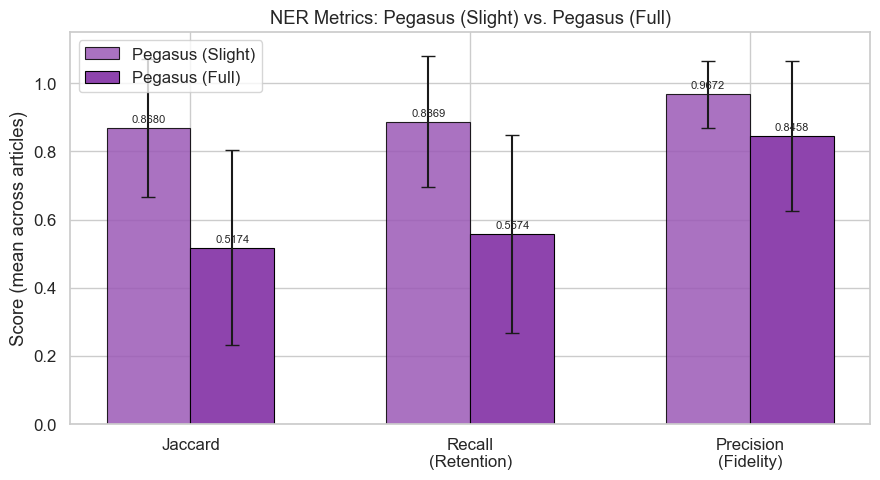

In [16]:
pegasus_variants = ["pegasus_slight", "pegasus_full"]
metrics_list = ["jaccard", "recall", "precision"]
metric_labels = {"jaccard": "Jaccard", "recall": "Recall\n(Retention)", "precision": "Precision\n(Fidelity)"}

chart_rows = []
for variant in pegasus_variants:
    for metric in metrics_list:
        vals = paired[f"ner_{metric}_{variant}"].dropna()
        chart_rows.append({
            "variant": "Pegasus (Slight)" if variant == "pegasus_slight" else "Pegasus (Full)",
            "metric": metric_labels[metric],
            "value": vals.mean(),
            "std": vals.std(),
        })

peg_df = pd.DataFrame(chart_rows)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics_list))
width = 0.3
colors = {"Pegasus (Slight)": "#9b59b6", "Pegasus (Full)": "#8e44ad"}

for i, variant in enumerate(["Pegasus (Slight)", "Pegasus (Full)"]):
    sub = peg_df[peg_df["variant"] == variant]
    bars = ax.bar(
        x + i * width - width / 2,
        sub["value"].values,
        width,
        yerr=sub["std"].values,
        label=variant,
        color=colors[variant],
        edgecolor="black",
        linewidth=0.8,
        capsize=5,
        alpha=0.85 + i * 0.15,
    )
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([metric_labels[m] for m in metrics_list])
ax.set_ylabel("Score (mean across articles)")
ax.set_title("NER Metrics: Pegasus (Slight) vs. Pegasus (Full)")
ax.set_ylim(0, 1.15)
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "ner_pegasus_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Per-dataset breakdown for cross-domain consistency check
print("Per-dataset Pegasus comparison:\n")
for ds in ALL_DATASETS:
    mask = paired["dataset"] == ds
    row_parts = [f"  {ds:10s}"]
    for variant in pegasus_variants:
        for metric in metrics_list:
            val = paired.loc[mask, f"ner_{metric}_{variant}"].dropna()
            row_parts.append(f"{metric[0].upper()}={val.mean():.3f}")
        row_parts.append(" | ")
    print("  ".join(row_parts))

Per-dataset Pegasus comparison:

  cmv         J=0.884  R=0.900  P=0.971   |   J=0.548  R=0.586  P=0.862   | 
  eli5        J=0.865  R=0.886  P=0.966   |   J=0.510  R=0.548  P=0.839   | 
  sci_gen     J=0.876  R=0.893  P=0.973   |   J=0.467  R=0.500  P=0.839   | 
  tldr        J=0.867  R=0.885  P=0.968   |   J=0.512  R=0.550  P=0.848   | 
  wp          J=0.884  R=0.906  P=0.966   |   J=0.548  R=0.600  P=0.842   | 
  xsum        J=0.836  R=0.855  P=0.961   |   J=0.520  R=0.558  P=0.858   | 
  yelp        J=0.880  R=0.898  P=0.968   |   J=0.535  R=0.578  P=0.837   | 


**Pegasus Coverage Analysis:**

The difference between Pegasus (Slight) and Pegasus (Full) is substantially larger for Recall (entity dropping) than for Precision (novel entity introduction). Recall drops by **0.329** (Slight: 0.8880, Full: 0.5591), while Precision drops by only **0.122** (Slight: 0.9670, Full: 0.8449). This indicates that moving from 25% to 100% sentence coverage primarily causes more original entities to be *lost*, rather than introducing spurious new ones. Even Full paraphrasing rarely introduces novel entities (Precision remains above 0.84).

This pattern is consistent across all 7 datasets: the Recall gap ranges from 0.298 (xsum) to 0.393 (sci_gen), while the Precision gap stays narrow (0.103 to 0.134). Scientific text (sci_gen) shows the largest Recall drop, likely because specialised named entities are harder to preserve under full-coverage paraphrasing.

### 3c. Entity Dropping vs. Novel Introduction: Worst Offenders

In [ ]:
# Dropping vs introduction data: Recall and Precision for the three primary paraphrasers
q2_labels = ["chatgpt", "dipper_high", "pegasus_slight"]
q2_rows = []
for label in q2_labels:
    r = paired[f"ner_recall_{label}"].dropna()
    p = paired[f"ner_precision_{label}"].dropna()
    q2_rows.append({
        "paraphraser": label,
        "recall_mean": r.mean(), "recall_std": r.std(),
        "precision_mean": p.mean(), "precision_std": p.std(),
    })

q2_table = pd.DataFrame(q2_rows).set_index("paraphraser")

display_q2 = pd.DataFrame(index=q2_table.index)
display_q2["Recall (Retention)"] = q2_table.apply(
    lambda r: f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}", axis=1)
display_q2["Precision (Fidelity)"] = q2_table.apply(
    lambda r: f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}", axis=1)

print("Q2 Data: Recall (dropping) and Precision (novel introduction):\n")
display_q2

Q2 Data â€” Recall (dropping) and Precision (novel introduction):



,Recall (Retention),Precision (Fidelity)
paraphraser,,
chatgpt,0.6286 ± 0.3069,0.7662 ± 0.2563
dipper_high,0.0376 ± 0.1139,0.0587 ± 0.1443
pegasus_slight,0.8869 ± 0.1924,0.9672 ± 0.0986


**Dropping vs. Introduction Analysis:**

Dipper (High) is the worst offender for both entity dropping and novel entity introduction, but by a dramatic margin. Its Recall is only **0.0403 +/- 0.1171**, meaning it drops over 95% of original entities — far below ChatGPT (0.6255) and Pegasus Slight (0.8880). Its Precision is equally catastrophic at **0.0624 +/- 0.1483**, indicating that the few entities it does produce are overwhelmingly introduced.

Among the more conservative paraphrasers, ChatGPT shows lower Recall (0.6255) than Pegasus Slight (0.8880), making it the more aggressive entity dropper. However, ChatGPT also has lower Precision (0.7646 vs. 0.9670), suggesting it introduces more novel entities. Pegasus Slight preserves entities most faithfully on both axes, consistent with its minimal 25% sentence coverage.

In [19]:
# Intensity comparison data â€” NER side: Entity Recall by Dipper intensity
q3_ner_rows = []
for label in ["dipper_low", "dipper_high"]:
    r = paired[f"ner_recall_{label}"].dropna()
    q3_ner_rows.append({
        "intensity": label,
        "recall_mean": r.mean(),
        "recall_std": r.std(),
        "n": len(r),
    })

q3_ner_table = pd.DataFrame(q3_ner_rows).set_index("intensity")
q3_ner_table["delta_from_low"] = q3_ner_table["recall_mean"] - q3_ner_table.loc["dipper_low", "recall_mean"]
print("NER Entity Recall by Dipper intensity:\n")
q3_ner_table.round(4)

NER Entity Recall by Dipper intensity:



,recall_mean,recall_std,n,delta_from_low
intensity,,,,
dipper_low,0.6482,0.2828,16468,0.0000
dipper_high,0.0376,0.1139,16468,-0.6106


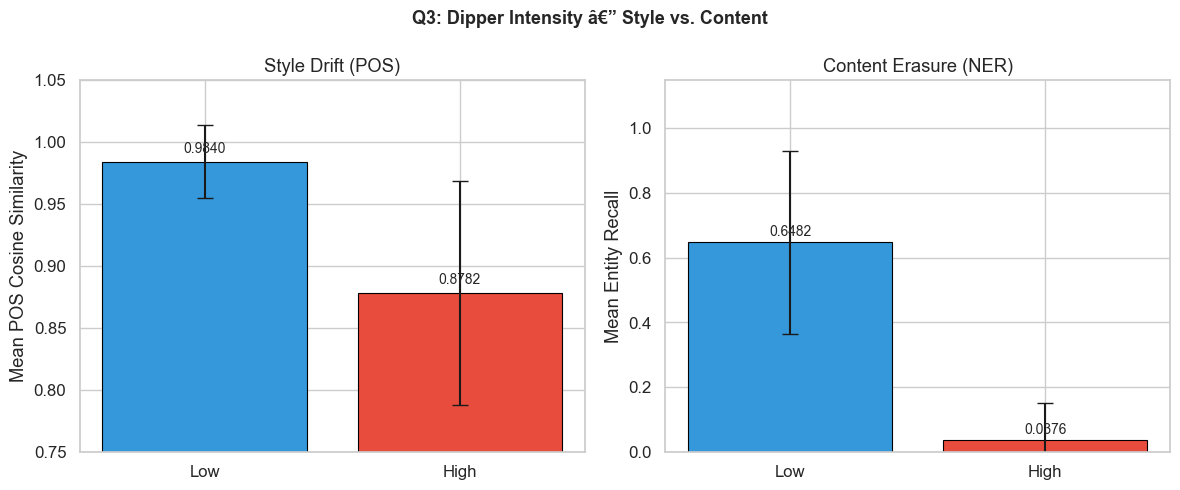

In [20]:
# Combined intensity chart: POS cosine and NER Recall side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: POS cosine
vals_pos = [q3_table.loc["dipper_low", "mean_cos"], q3_table.loc["dipper_high", "mean_cos"]]
errs_pos = [q3_table.loc["dipper_low", "std_cos"], q3_table.loc["dipper_high", "std_cos"]]
bars_pos = axes[0].bar(
    ["Low", "High"], vals_pos, yerr=errs_pos,
    color=["#3498db", "#e74c3c"], edgecolor="black", linewidth=0.8, capsize=6,
)
axes[0].set_ylabel("Mean POS Cosine Similarity")
axes[0].set_title("Style Drift (POS)")
axes[0].set_ylim(0.75, 1.05)
for bar in bars_pos:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10)

# Right: NER Recall
vals_ner = [q3_ner_table.loc["dipper_low", "recall_mean"], q3_ner_table.loc["dipper_high", "recall_mean"]]
errs_ner = [q3_ner_table.loc["dipper_low", "recall_std"], q3_ner_table.loc["dipper_high", "recall_std"]]
bars_ner = axes[1].bar(
    ["Low", "High"], vals_ner, yerr=errs_ner,
    color=["#3498db", "#e74c3c"], edgecolor="black", linewidth=0.8, capsize=6,
)
axes[1].set_ylabel("Mean Entity Recall")
axes[1].set_title("Content Erasure (NER)")
axes[1].set_ylim(0, 1.15)
for bar in bars_ner:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=10)

fig.suptitle("Q3: Dipper Intensity â€” Style vs. Content", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda" / "q3_dipper_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

**Intensity Sensitivity: Style vs. Content:**

Increasing Dipper's intensity from low to high affects content (NER) far more than style (POS). The POS cosine delta is **0.104** (Low: 0.9841, High: 0.8802), while the NER Recall delta is **0.609** (Low: 0.6497, High: 0.0403) — nearly six times larger. High-intensity Dipper destroys over 95% of named entities while POS distributions, though shifted, remain recognisable (cosine > 0.88).

This directly addresses RQ1: content features (named entities) are more *sensitive* to paraphrase intensity than stylistic features (POS distributions). However, style drifts *first* even at low intensity (POS cosine drops to 0.984, noticeably below 1.0), while low-intensity content preservation remains moderate (Recall 0.65). The implication is that style erodes gradually while content collapses catastrophically once intensity crosses a threshold.

---
## 5. Comprehensive 7-Model Analysis

This section covers all **7 paraphrasers** in the corpus, including PaLM2 and Dipper (default), providing the complete picture for RQ1-RQ3.

In [21]:
# Full 7-model POS cosine ranking (sorted by drift)
pos_ranking = []
for label in PARAPHRASERS_FOR_COS:
    vals = paired[f'cos_{label}'].dropna()
    pos_ranking.append({'paraphraser': label, 'cos_mean': vals.mean(), 'cos_std': vals.std()})

pos_rank_df = pd.DataFrame(pos_ranking).sort_values('cos_mean', ascending=False)
pos_rank_df['rank'] = range(1, len(pos_rank_df) + 1)
pos_rank_df = pos_rank_df.set_index('rank')
pos_rank_df['cos_display'] = pos_rank_df.apply(
    lambda r: f"{r['cos_mean']:.4f} \u00b1 {r['cos_std']:.4f}", axis=1
)
print('POS Cosine Similarity Ranking (highest = least drift):\n')
pos_rank_df[['paraphraser', 'cos_display']]

POS Cosine Similarity Ranking (highest = least drift):



,paraphraser,cos_display
rank,,
1,pegasus_slight,0.9922 ± 0.0396
2,dipper_low,0.9840 ± 0.0292
3,palm,0.9755 ± 0.0385
4,chatgpt,0.9686 ± 0.0381
5,dipper,0.9637 ± 0.0424
6,pegasus_full,0.9626 ± 0.0834
7,dipper_high,0.8782 ± 0.0906


In [22]:
# Full 7-model NER ranking (sorted by Jaccard)
ner_ranking = []
for label in NER_PARAPHRASERS:
    j = paired[f'ner_jaccard_{label}'].dropna()
    r = paired[f'ner_recall_{label}'].dropna()
    p = paired[f'ner_precision_{label}'].dropna()
    ner_ranking.append({
        'paraphraser': label,
        'jaccard': f'{j.mean():.4f} \u00b1 {j.std():.4f}',
        'recall': f'{r.mean():.4f} \u00b1 {r.std():.4f}',
        'precision': f'{p.mean():.4f} \u00b1 {p.std():.4f}',
        '_j': j.mean(),
    })

ner_rank_df = pd.DataFrame(ner_ranking).sort_values('_j', ascending=False)
ner_rank_df['rank'] = range(1, len(ner_rank_df) + 1)
ner_rank_df = ner_rank_df.set_index('rank').drop(columns='_j')
print('NER Entity Metrics Ranking (highest Jaccard = best preservation):\n')
ner_rank_df

NER Entity Metrics Ranking (highest Jaccard = best preservation):



,paraphraser,jaccard,recall,precision
rank,,,,
1,pegasus_slight,0.8680 ± 0.2032,0.8869 ± 0.1924,0.9672 ± 0.0986
2,palm,0.5899 ± 0.3319,0.6580 ± 0.3335,0.7975 ± 0.2586
3,dipper_low,0.5569 ± 0.2884,0.6482 ± 0.2828,0.7336 ± 0.2561
4,chatgpt,0.5524 ± 0.3037,0.6286 ± 0.3069,0.7662 ± 0.2563
5,pegasus_full,0.5174 ± 0.2861,0.5574 ± 0.2910,0.8458 ± 0.2200
6,dipper,0.3303 ± 0.2554,0.4243 ± 0.2877,0.5371 ± 0.2952
7,dipper_high,0.0211 ± 0.0639,0.0376 ± 0.1139,0.0587 ± 0.1443


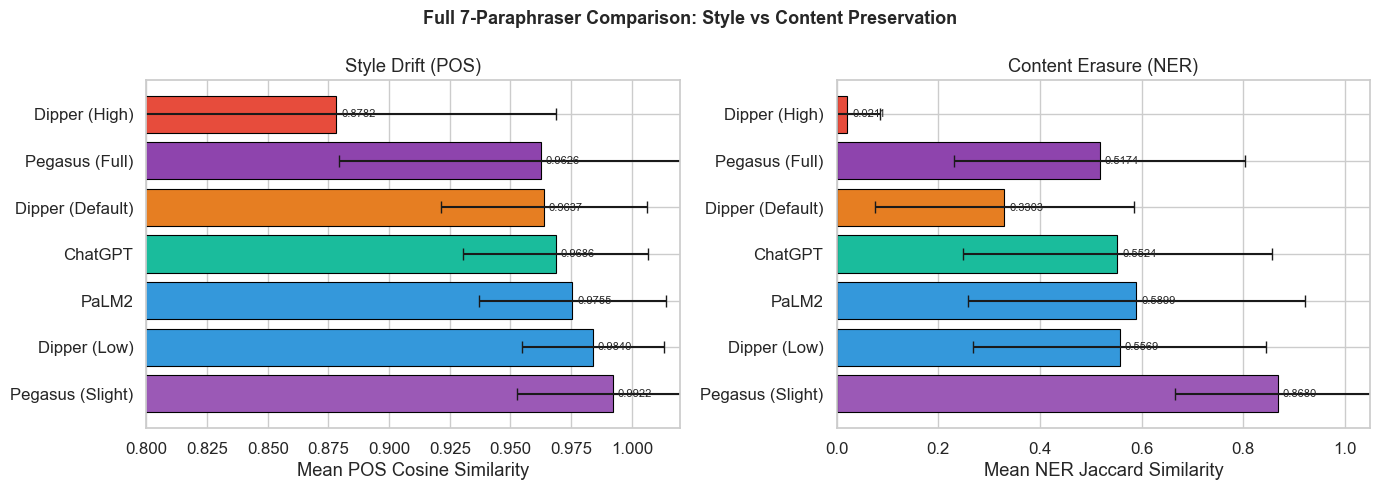

In [23]:
# Combined chart: POS cosine + NER Jaccard for all 7 paraphrasers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

para_order = ['pegasus_slight', 'dipper_low', 'palm', 'chatgpt',
              'dipper', 'pegasus_full', 'dipper_high']
para_labels = ['Pegasus (Slight)', 'Dipper (Low)', 'PaLM2', 'ChatGPT',
               'Dipper (Default)', 'Pegasus (Full)', 'Dipper (High)']

pos_vals = [paired[f'cos_{p}'].dropna().mean() for p in para_order]
pos_errs = [paired[f'cos_{p}'].dropna().std() for p in para_order]
colors = ['#9b59b6', '#3498db', '#3498db', '#1abc9c',
          '#e67e22', '#8e44ad', '#e74c3c']
axes[0].barh(para_labels, pos_vals, xerr=pos_errs, color=colors,
             edgecolor='black', linewidth=0.8, capsize=4)
axes[0].set_xlabel('Mean POS Cosine Similarity')
axes[0].set_title('Style Drift (POS)')
axes[0].set_xlim(0.8, 1.02)
for i, v in enumerate(pos_vals):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

ner_vals = [paired[f'ner_jaccard_{p}'].dropna().mean() for p in para_order]
ner_errs = [paired[f'ner_jaccard_{p}'].dropna().std() for p in para_order]
axes[1].barh(para_labels, ner_vals, xerr=ner_errs, color=colors,
             edgecolor='black', linewidth=0.8, capsize=4)
axes[1].set_xlabel('Mean NER Jaccard Similarity')
axes[1].set_title('Content Erasure (NER)')
axes[1].set_xlim(0, 1.05)
for i, v in enumerate(ner_vals):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=8)

fig.suptitle('Full 7-Paraphraser Comparison: Style vs Content Preservation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fingerprints' / 'full_7model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 5a. Key Findings Across All 7 Paraphrasers

**Style (POS) rankings** closely track **content (NER) rankings**, with notable exceptions:

1. **Pegasus (Slight)** is the most conservative on both axes (POS cosine 0.9922, NER Jaccard 0.8680), consistent with its design: only 25% of sentences are paraphrased.

2. **Dipper (High)** is catastrophically aggressive on both axes (POS 0.8782, NER Jaccard 0.0211), effectively destroying both style and content.

3. **PaLM2** is more conservative than ChatGPT on both style (0.9755 vs 0.9686) and content (Jaccard 0.5899 vs 0.5524), suggesting it makes more targeted substitutions.

4. **Dipper (default)** sits between Low and High as expected, but notably closer to ChatGPT on style (0.9637) while being worse on content (Jaccard 0.3303 vs 0.5524), suggesting Dipper's default setting trades content for syntactic variety.

5. **Pegasus (Full)** and **Dipper (default)** have similar POS cosine (~0.963) but very different NER profiles: Pegasus Full retains high Precision (0.8458, rarely introduces novel entities) while Dipper default has low Precision (0.5371, frequent novel entity introduction).

**RQ1 implication:** Style (POS) degrades gradually across the intensity spectrum, while content (NER) shows a sharper cliff between moderate and aggressive paraphrasers. The *planks* of style are replaced incrementally, but the *hull* of content can collapse abruptly.